# EDA

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
def get_data(directory="data", filename=""):
    file_path = os.path.join(directory, filename)
    return pd.read_csv(file_path)

In [3]:
raw_training_data = get_data(filename="training.csv")
raw_training_data.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [4]:
raw_training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


In [5]:
num_labels = len(raw_training_data["label"].unique())
print(f"Number of labels in the data: {num_labels}")

Number of labels in the data: 6


In [6]:
idx_to_label = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise"
}

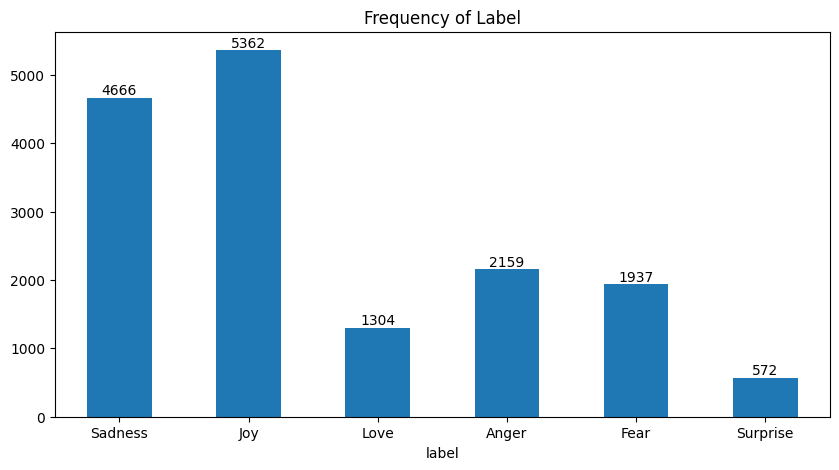

In [7]:
label_frequency = raw_training_data["label"].value_counts().sort_index().rename(index=idx_to_label)
ax = label_frequency.plot(kind='bar', 
                          rot=0,
                          figsize=(10, 5),
                          title="Frequency of Label")
for i, v in enumerate(label_frequency.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [8]:
l = [len(sentence) for sentence in raw_training_data['text']]
length = pd.Series(l)
print(length.describe())

count    16000.000000
mean        96.845812
std         55.904953
min          7.000000
25%         53.000000
50%         86.000000
75%        129.000000
max        300.000000
dtype: float64


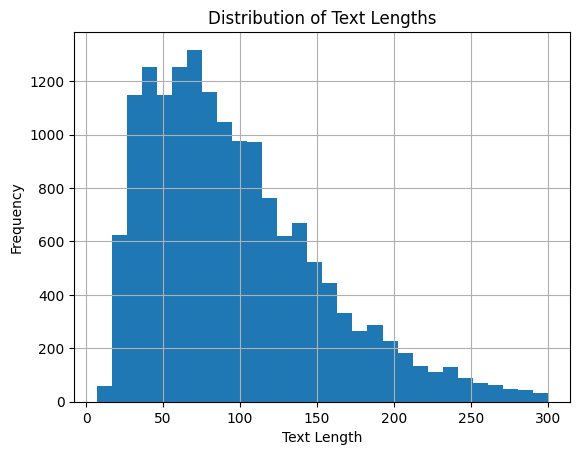

In [9]:
length.hist(bins=30)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths")
plt.show()

# LSTM

## Prepare training data

In [10]:
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
import torch
from nltk import word_tokenize

In [11]:
# Embedding using a global embedding vector - "glove.6B.100d.txt" (https://nlp.stanford.edu/projects/glove/)
glove_path = "glove.6B/glove.6B.100d.txt"
embedding_dim = 100

glove_dict = {}

with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_dict[word] = vector

In [12]:
# Build a vocabulary from the training set
def build_vocabulary(data):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    all_tokens = []
    for sentence in data["text"]:
        all_tokens.extend([token for token in word_tokenize(sentence)])
    for word, _ in Counter(all_tokens).items():
        vocab[word] = len(vocab)

    
    return vocab

vocab = build_vocabulary(raw_training_data)
print(vocab)

{'<PAD>': 0, '<UNK>': 1, 'i': 2, 'didnt': 3, 'feel': 4, 'humiliated': 5, 'can': 6, 'go': 7, 'from': 8, 'feeling': 9, 'so': 10, 'hopeless': 11, 'to': 12, 'damned': 13, 'hopeful': 14, 'just': 15, 'being': 16, 'around': 17, 'someone': 18, 'who': 19, 'cares': 20, 'and': 21, 'is': 22, 'awake': 23, 'im': 24, 'grabbing': 25, 'a': 26, 'minute': 27, 'post': 28, 'greedy': 29, 'wrong': 30, 'am': 31, 'ever': 32, 'nostalgic': 33, 'about': 34, 'the': 35, 'fireplace': 36, 'will': 37, 'know': 38, 'that': 39, 'it': 40, 'still': 41, 'on': 42, 'property': 43, 'grouchy': 44, 'ive': 45, 'been': 46, 'little': 47, 'burdened': 48, 'lately': 49, 'wasnt': 50, 'sure': 51, 'why': 52, 'was': 53, 'taking': 54, 'or': 55, 'milligrams': 56, 'times': 57, 'recommended': 58, 'amount': 59, 'fallen': 60, 'asleep': 61, 'lot': 62, 'faster': 63, 'but': 64, 'also': 65, 'like': 66, 'funny': 67, 'as': 68, 'confused': 69, 'life': 70, 'teenager': 71, 'jaded': 72, 'year': 73, 'old': 74, 'man': 75, 'have': 76, 'with': 77, 'petronas'

In [ ]:
def build_embedding_matrix(vocab):
    embedding_matrix = np.zeros((len(vocab), embedding_dim))

    for word, idx in vocab.items():
        if word in glove_dict:
            embedding_matrix[idx] = glove_dict[word]
        else:
            embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
    
    return embedding_matrix

embedding_matrix = build_embedding_matrix(vocab)

[[ 1.53857897  1.19915903 -0.35131516 ... -0.35865141 -0.24628375
   0.18795302]
 [ 0.65108335  0.13844323  0.05341707 ...  0.59984227 -1.31459642
   0.49699972]
 [-0.046539    0.61966002  0.56647003 ... -0.37616    -0.032502
   0.80620003]
 ...
 [ 1.10699999  0.05606    -1.04429996 ... -0.28536001  0.1207
   0.065775  ]
 [-0.54747999  0.47907001  0.29262999 ...  0.17169     0.71335
  -0.23613   ]
 [-0.52122003 -0.11345     0.057756   ...  0.48345    -0.041026
  -0.107     ]]


In [16]:
np.save("space/model/lstm/embedding_matrix.npy", embedding_matrix)

In [14]:
def prepare_data(data, vocab):
    # Return the padded text and labels 
    data["text"] = data["text"].str.lower()
    data["tokens"] = data["text"].apply(word_tokenize)

    data['ids'] = data['tokens'].apply(
        lambda tokens: [vocab.get(tok, vocab['<UNK>']) for tok in tokens]
    )

    sequences = [torch.tensor(seq) for seq in data['ids']]

    padded = pad_sequence(sequences, batch_first=True, padding_value=0)

    return padded, data['label']

training_data, label = prepare_data(data=raw_training_data, vocab=vocab)

## LSTM Model

In [15]:
import torch.nn as nn
from huggingface_hub import PyTorchModelHubMixin

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
class LSTMClassifier(nn.Module, PyTorchModelHubMixin):
    def __init__(self, 
                 embedding_dim=100, 
                 hidden_dim=256, 
                 output_dim=6, 
                 n_layers=2, 
                 bidirectional=True, 
                 dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=True
        )
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=n_layers, 
                            bidirectional=bidirectional, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(lstm_output_dim, output_dim)
        
    def forward(self, text, text_lengths=None):
        embedded = self.dropout(self.embedding(text))
        _, (hidden, _) = self.lstm(embedded)
        
        if self.lstm.bidirectional:
            hidden = self.dropout(torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1))
        else:
            hidden = self.dropout(hidden[-1, :, :])
        
        predictions = self.fc(hidden)
        
        return predictions

model_lstm = LSTMClassifier(output_dim=num_labels)
print(model_lstm)
print(f"\nTotal parameters: {sum(p.numel() for p in model_lstm.parameters()):,}")

LSTMClassifier(
  (embedding): Embedding(15212, 100)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=6, bias=True)
)

Total parameters: 3,834,422


## Training

In [17]:
from torch.utils.data import TensorDataset, DataLoader
from safetensors.torch import save_file

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_lstm = model_lstm.to(device)
print(f"Model on device: {device}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

Model on device: cuda


In [19]:
def train_epoch(model, iterator, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for _, batch in enumerate(iterator):
        optimizer.zero_grad()
        
        text = batch['text'].to(device)
        labels = batch['label'].to(device)
        
        predictions = model(text)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(predictions.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return epoch_loss / len(iterator), correct / total

In [20]:
class BatchWrapper:
    def __init__(self, loader):
        self.loader = loader
    
    def __iter__(self):
        for batch in self.loader:
            text, label = batch
            yield {'text': text, 'label': label}
    
    def __len__(self):
        return len(self.loader)

In [22]:
def wrap_data(dataset, label, batch_size=32):
    label_torch = torch.tensor(label, dtype=torch.long)
    dataset_tensor = TensorDataset(dataset, label_torch)
    loader = DataLoader(dataset_tensor, batch_size=batch_size, shuffle=True)
    return BatchWrapper(loader)

In [23]:
def train(model, data, label, link, batch_size=32, num_epochs=10):
    train = wrap_data(data, label, batch_size)

    patience, patience_counter = 3, 0   

    training_losses = []
    training_accs = []

    best_train_acc = 0

    print("START TRAINING")
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train, optimizer, criterion, device)
        training_losses.append(train_loss)
        training_accs.append(train_acc)
        
        if epoch == 0:
            best_train_acc = train_acc
        elif train_acc > best_train_acc:
            best_train_acc = train_acc
            save_file(model.state_dict(), link)
            patience_counter = 0
        else:
            patience_counter += 1

        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    print(f"Best training accuracy: {best_train_acc:.4f}")


In [24]:
def fine_tune(model, val_data, val_label, batch_size=16, num_epochs=5):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True

    validation = wrap_data(val_data, val_label, batch_size)
    ft_optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-6)
    model.train()

    validation_losses = []
    validation_accs = []

    for epoch in range(num_epochs):
        val_loss, val_acc = train_epoch(model, validation, ft_optimizer, criterion, device)
        validation_losses.append(val_loss)
        validation_accs.append(val_acc)
        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

In [25]:
raw_validation_data = get_data(filename="validation.csv")
validation_data, validation_label = prepare_data(data=raw_validation_data, vocab=vocab)

In [ ]:
train(model_lstm, training_data, label, link="space/model/lstm/lstm_model.safetensors")

START TRAINING
Epoch 1/10 | Train Loss: 1.4353 | Train Acc: 0.4494
Epoch 2/10 | Train Loss: 0.9915 | Train Acc: 0.6451
Epoch 3/10 | Train Loss: 0.6165 | Train Acc: 0.7730
Epoch 4/10 | Train Loss: 0.4193 | Train Acc: 0.8451
Epoch 5/10 | Train Loss: 0.3189 | Train Acc: 0.8793
Epoch 6/10 | Train Loss: 0.2519 | Train Acc: 0.9005
Epoch 7/10 | Train Loss: 0.2233 | Train Acc: 0.9113
Epoch 8/10 | Train Loss: 0.2147 | Train Acc: 0.9118
Epoch 9/10 | Train Loss: 0.2134 | Train Acc: 0.9100
Epoch 10/10 | Train Loss: 0.1990 | Train Acc: 0.9144
Best training accuracy: 0.9144


In [ ]:
save_file(model_lstm.state_dict(), "space/model/lstm/lstm_model.safetensors")

## Testing the Model

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
import seaborn as sns

In [29]:
def get_prediction_lstm(model, iterator, device):
    model.eval()

    predict = []
    target = []


    with torch.no_grad():
        for batch in iterator:
            text = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            predictions = model(text)
            _, predicted = torch.max(predictions.data, 1)
            predict.append(predicted)
            target.append(labels)

    predict = torch.cat(predict, axis=0)
    target = torch.cat(target, axis=0)

    return predict, target

In [30]:
raw_test_data = get_data(filename="test.csv")
test_data, test_label = prepare_data(data=raw_test_data, vocab=vocab)
test = wrap_data(test_data, test_label)

In [31]:
predicted, target = get_prediction_lstm(model_lstm, test, device)
predicted = predicted.cpu().numpy()
target = target.cpu().numpy()

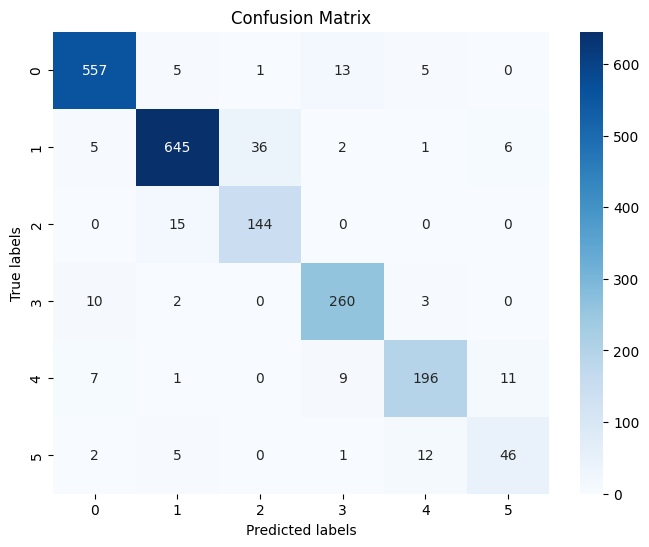

In [32]:
cm = confusion_matrix(target, predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()

In [34]:
accuracy = accuracy_score(target, predicted)
precision = precision_score(target, predicted, average='weighted')
recall = recall_score(target, predicted, average="weighted")
print(f"Accuracy: {accuracy:.3f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Accuracy: 0.923 | Precision: 0.924 | Recall: 0.923


In [33]:
print(classification_report(target, predicted))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       581
           1       0.96      0.93      0.94       695
           2       0.80      0.91      0.85       159
           3       0.91      0.95      0.93       275
           4       0.90      0.88      0.89       224
           5       0.73      0.70      0.71        66

    accuracy                           0.92      2000
   macro avg       0.88      0.88      0.88      2000
weighted avg       0.93      0.92      0.92      2000



# Transformer

## Prepare Training Set

In [13]:
import torch
from transformers import AutoTokenizer
from torch.utils.data import Dataset, DataLoader

In [11]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [12]:
texts = raw_training_data["text"].tolist()
encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    return_tensors = None
)

In [13]:
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        super().__init__()
        self.encodings = encodings
        self.labels = labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

labels = raw_training_data["label"].tolist()
train_dataset = TextDataset(encodings, labels)

In [14]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Import pre-trained model

In [12]:
from transformers import AutoModelForSequenceClassification

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
model_transformer = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=6)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6736.21it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
model_transformer.to(device)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## Training the Model

In [21]:
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm
from sklearn.metrics import accuracy_score

In [22]:
optimizer = AdamW(model_transformer.parameters(), lr=1e-5, weight_decay=0.01)

In [23]:
num_epochs = 5
num_training_steps = num_epochs * len(train_loader)

lr_scheduler = get_scheduler(
    "linear",          
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

In [24]:
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training"):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [25]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc

In [26]:
raw_validation_data = get_data(filename="validation.csv")
texts_validation = raw_validation_data["text"].tolist()
labels_validation = raw_validation_data["label"].tolist()

In [27]:
encodings = tokenizer(
    texts_validation,
    truncation=True,
    padding=True,
    return_tensors = None
)
validation_dataset = TextDataset(encodings, labels_validation)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=True)

In [ ]:
def train(model, train_loader, validation_loader, optimizer, lr_scheduler, num_epochs, link):
    best_val_acc = 0
    patience, patience_counter = 3, 0   

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, lr_scheduler)
        val_acc    = evaluate(model, validation_loader)

        print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}", end="\n\n")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            model.save_pretrained(link)
            tokenizer.save_pretrained(link)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    print(f"Best validation accuracy: {best_val_acc:.4f}")

train(model_transformer, train_loader, validation_loader, optimizer, lr_scheduler, num_epochs, link="./space/model/transformer_bert")

Evaluating: 100%|██████████| 125/125 [00:05<00:00, 24.03it/s]


Epoch 1 | Loss: 0.9282 | Val Acc: 0.9115



Evaluating: 100%|██████████| 125/125 [00:05<00:00, 23.27it/s]


Epoch 2 | Loss: 0.2126 | Val Acc: 0.9210



Evaluating: 100%|██████████| 125/125 [00:05<00:00, 23.80it/s]


Epoch 3 | Loss: 0.1438 | Val Acc: 0.9355



Evaluating: 100%|██████████| 125/125 [00:05<00:00, 24.07it/s]


Epoch 4 | Loss: 0.1085 | Val Acc: 0.9405



Evaluating: 100%|██████████| 125/125 [00:05<00:00, 22.09it/s]

Epoch 5 | Loss: 0.0902 | Val Acc: 0.9390

Best validation accuracy: 0.9405


## Testing

In [33]:
from sklearn.metrics import classification_report, confusion_matrix

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [28]:
model_transformer = AutoModelForSequenceClassification.from_pretrained("./best_model")
model_transformer.to(device)
tokenizer = AutoTokenizer.from_pretrained("./best_model")
model_transformer.eval()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7431.51it/s]


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [29]:
raw_test_data = get_data(filename="test.csv")
texts_test = raw_test_data["text"].tolist()
target_test = raw_test_data["label"].tolist()

In [30]:
def predict(model, tokenizer, texts: list[str], device) -> list[int]:
    inputs = tokenizer(texts, truncation=True, padding=True,
                       max_length=512, return_tensors="pt")

    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    return logits.argmax(dim=-1).tolist()

In [31]:
predicted = predict(model_transformer, tokenizer, texts_test, device)

In [34]:
cr = classification_report(target_test, predicted)
print(cr)

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       581
           1       0.96      0.93      0.95       695
           2       0.79      0.89      0.84       159
           3       0.95      0.92      0.94       275
           4       0.88      0.94      0.91       224
           5       0.84      0.64      0.72        66

    accuracy                           0.93      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.93      0.93      0.93      2000



In [37]:
import seaborn as sns

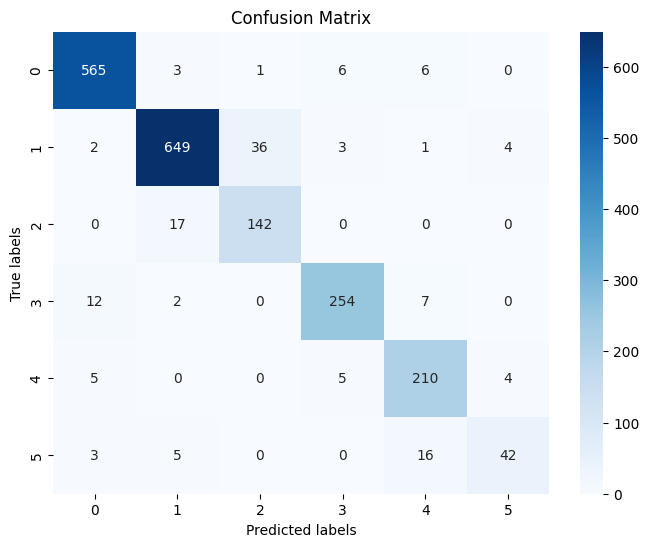

In [38]:
cm = confusion_matrix(target_test, predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Confusion Matrix")
plt.show()